In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [1]:
#Section 1: Imports and Setup

# DATA HANDLING
import numpy as np # numpy = numerical arrays + maths functions (log, sqrt, etc.)
import pandas as pd # pandas = table handling (DataFrames), like Excel in code
import matplotlib.pyplot as plt # matplotlib = drawing charts
import joblib # joblib = saving/loading trained models to .pkl files

# DATA PRE-PROCESSING
from sklearn.preprocessing import StandardScaler # rescales features to mean 0, std 1
from sklearn.decomposition import PCA # squashes 3D data to 2D so we can plot it

# IMPORT THE THREE CLUSTERING ALGORITHMS
from sklearn.cluster import KMeans, DBSCAN # KMeans = partition-based, DBSCAN = density-based
from sklearn.mixture import GaussianMixture # GMM = probabilistic model-based
from sklearn.neighbors import NearestNeighbors # used to build the k-distance plot for DBSCAN

# IMPORT THE EVALUATION METRICS
from sklearn.metrics import (
    silhouette_score, # higher is better: are points closer to own cluster than others?
    davies_bouldin_score, # Lower is better: how similar is each cluster to its nearest neighbour?
    calinski_harabasz_score, # higher is better: between-cluster spread / within-cluster spread
)

# REPRODUCIBILITY
# Clustering uses randomness (e.g. where K-Means places its first centroids).
# Fixing the "seed" to 42 means we get the SAME result every time we run it.
# Without this, our report numbers would change on every run.
RANDOM_STATE = 42

# Display numbers with thousands separators and 2 decimals. (e.g. 4,921.53)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Section 2: Data Loading and Cleaning

# read_excel() loads one worksheet into a DataFrame (a table)
# sheet_name tells it WHICH worksheet to read
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# concat() stacks the two tables on top of each other into one
# ignore_index = True renumbers the rows 0,1,2,... instead of restarting at 0 for df2
df = pd.concat([df1, df2], ignore_index=True)

# The raw column is named "Customer ID" WITH A SPACE, which is awkward in code
# This loop strips spaces from every column name: "Customer ID" -> "CustomerID"
df.columns = [c.strip().replace(' ', '') for c in df.columns]

# Keep an untouched master copy in memory
# WHY: the cleaning cell below overwrites df. Without this backup, re-running the cleaning cell would filter the ALREADY-filtered data and show wrong counts
df_raw = df.copy()

print(f"Raw records: {len(df):,}")
print("Columns:", list(df.columns))

Raw records: 1,067,371
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [3]:
df = df_raw.copy()
print(f"{'Raw:':35s}{len(df):>12,}")

# FILTER 1: Remove rows with no Customer ID

# Why: these are guest checkouts. We cannot segment a customer we cannot identify
# dropna(subset=[...]) drops rows where that specific column is empty (NaN)
df = df.dropna(subset=['CustomerID'])
print(f"{'After dropping null CustomerID:':35s}{len(df):>12,}")

# FILTER 2: Remove cancelled invoices

# Why: an invoice starting with "C" is a cancellation - a reversed sale, not a real purchase.
# .astype(str)          -> treat invoice numbers as text so we can check the first letter
# .str.startswith('C')  -> True if it begins with C
# ~                     -> means NOT, so we KEEP the rows that do NOT start with C
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"{'After removing cancellations:':35s}{len(df):>12,}")

# FILTER 3: Remove non-positive quantity or price

# Why: negative/zero values are returns or data-entry errors, not purchases
# The & means AND - both conditions must be true to keep the row
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f"{'After removing non-positive:':35s}{len(df):>12,}")

# FILTER 4: Remove exact duplicate rows

# Why: the two worksheets overlap in early Dec 2010, creating duplicated transactions
df = df.drop_duplicates()
print(f"{'After removing duplicates:':35s}{len(df):>12,}")

# Convert Customer ID from decimal (12346.0) to whole number (12346) for tidiness
df['CustomerID'] = df['CustomerID'].astype(int)

# Create the revenue column we need for the Monetary feature
# Each row is ONE line item, so its value = how many units x price per unit
df['TotalPrice'] = df['Quantity'] * df['Price']

# nunique() counts how many DIFFERENT customer IDs exist
print(f"\nUnique customers: {df['CustomerID'].nunique():,}")

Raw:                                  1,067,371
After dropping null CustomerID:         824,364
After removing cancellations:           805,620
After removing non-positive:            805,549
After removing duplicates:              779,425

Unique customers: 5,878


In [4]:
# Section 3: RFM Feature Engineering

# A "snapshot date" is the pretend date we are standing on when measuring recency
# We use one day AFTER the final transaction, so the most recent customer has Recency = 1
# rather than 0 (which would break the log transform later)
# df['InvoiceDate'].max()  -> the latest transaction date in the whole dataset
# pd.Timedelta(days=1)     -> add one day to it
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

# groupby('CustomerID') = "process each customer's rows as one group"
# .agg(...) = "for each group, calculate these summary numbers"
rfm = df.groupby('CustomerID').agg(

    # RECENCY: Days since this customer's last purchase
    # x is all the InvoiceDates for ONE customer
    # x.max() is their most recent purchase date
    # (snapshot - that date).days converts the gap into a whole number of days
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),

    # FREQUENCY: How many separate ORDERS they placed
    # 'nunique' counts DISTINCT invoice numbers
    # We use nunique (not count) because one order can have 20 product lines - that is still ONE purchase occasion, not 20
    Frequency=('Invoice', 'nunique'),

    # MONETARY: Total money spent, summing the TotalPrice of every line they bought
    Monetary=('TotalPrice', 'sum'),
)

print(f"RFM table shape: {rfm.shape}") # (rows, columns) -> should be (5878, 3)
rfm.head() # show the first 5 customers

Snapshot date: 2011-12-10 12:50:00
RFM table shape: (5878, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,12,"77,556.46"
12347,2,8,"4,921.53"
12348,75,5,"2,019.40"
12349,19,4,"4,428.69"
12350,310,1,334.40


In [5]:
# describe() prints count, mean, std, min, quartiles and max for each column
# Look at Monetary: the max is enormous compared with the median - that is the skew problem
rfm.describe()

,Recency,Frequency,Monetary
count,"5,878.00","5,878.00","5,878.00"
mean,201.33,6.29,"2,955.90"
std,209.34,13.01,"14,440.85"
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,"2,248.30"
max,739.00,398.00,"580,987.04"


In [6]:
# Section 4: Transforming and Scaling

# skew() measures lopsidedness. 0 = symmetric. Above 1 = highly skewed
# We check BEFORE transforming so we can prove the transform was necessary
print("Skew BEFORE log transform:")
print(rfm.skew().round(3))

Skew BEFORE log transform:
Recency      0.89
Frequency   12.64
Monetary    25.07
dtype: float64


In [7]:
# log1p(x) computes log(1 + x)
# WHY log:  it converts "how many TIMES bigger" into "how far apart".
#           A doubling of spend becomes the same distance whether from 100 or 100,000.
#           This pulls the extreme spenders back in line with everyone else.
# WHY the +1: log(0) is undefined and would crash. Adding 1 guarantees a safe input.
rfm_log = np.log1p(rfm)

# StandardScaler rescales each column to mean = 0 and standard deviation = 1
# WHY: log fixed the SHAPE (removed skew) but the columns still sit on different ranges
#      Scaling makes sure Recency, Frequency and Monetary all carry equal weight
scaler = StandardScaler()

# fit_transform does two jobs at once:
# fit()       -> learn the mean and std of each column
# transform() -> apply the rescaling using what it learned
# X is now the final numeric matrix that ALL THREE algorithms will use
X = scaler.fit_transform(rfm_log)

print("Skew AFTER log transform:")
print(rfm_log.skew().round(3))
print(f"\nScaled matrix shape: {X.shape}")

Skew AFTER log transform:
Recency     -0.49
Frequency    1.00
Monetary     0.27
dtype: float64

Scaled matrix shape: (5878, 3)


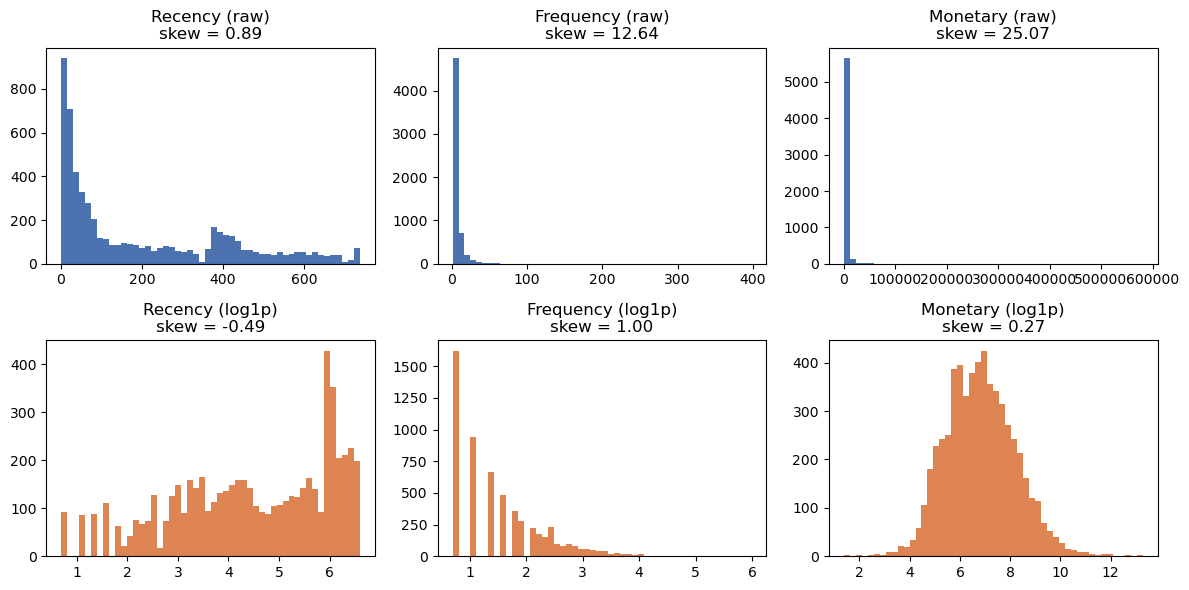

In [8]:
# Draw 6 histograms: raw on the top row, logged on the bottom row
# subplots(2, 3) creates a 2-row x 3-column grid of charts
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# Enumerate() gives us both the position (i = 0,1,2) and the name of each column
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    # axes[row, column] picks which little chart to draw on
    axes[0, i].hist(rfm[col], bins=50, color='#4C72B0') # top row = raw values
    axes[0, i].set_title(f'{col} (raw)\nskew = {rfm[col].skew():.2f}')

    axes[1, i].hist(rfm_log[col], bins=50, color='#DD8452') # bottom row = logged values
    axes[1, i].set_title(f'{col} (log1p)\nskew = {rfm_log[col].skew():.2f}')

plt.tight_layout() # Stop the titles overlapping
plt.savefig('fig_skew.png', dpi=150) # Save for the report (Figure 3.2)
plt.show()

In [9]:
# Section 5: K-Means Clustering (Chen Tian Yu)

# Test every k from 2 to 10 and record how good each one is
ks = range(2, 11) # range(2,11) gives 2,3,4,...,10 (11 is excluded)
inertias, sils, dbs, chs = [], [], [], [] # Empty lists to collect results

for k in ks:
    # Build a K-Means model for this value of k
    # n_clusters   = how many groups to find
    # n_init=10    = run the whole algorithm 10 times from different random starts and keep the best. Protects against a bad random start
    # random_state = fixes the randomness so results are reproducible
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)

    # fit_predict() trains the model AND returns the cluster number for each customer
    labels = km.fit_predict(X)

    # INERTIA: Total squared distance from each point to its own centre
    # Lower = Tighter clusters. It ALWAYS falls as k rises, so we look for the "elbow"
    inertias.append(km.inertia_)

    # Record all three evaluation metrics for this k
    sils.append(silhouette_score(X, labels))
    dbs.append(davies_bouldin_score(X, labels))
    chs.append(calinski_harabasz_score(X, labels))

# Put the results into a table so we can read them easily
selection = pd.DataFrame({'k': list(ks), 'inertia': inertias,'silhouette': sils, 'davies_bouldin': dbs,'calinski_harabasz': chs})
selection.round(4)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,"8,588.99",0.44,0.87,"6,187.99"
1,3,"6,354.34",0.35,1.04,"5,214.62"
2,4,"4,921.23",0.36,0.93,"5,058.07"
3,5,"4,099.11",0.34,0.95,"4,848.23"
4,6,"3,554.70",0.33,0.96,"4,651.57"
5,7,"3,194.50",0.31,0.98,"4,422.95"
6,8,"2,902.43",0.30,0.99,"4,256.43"
7,9,"2,656.56",0.29,1.00,"4,136.22"
8,10,"2,467.38",0.29,1.00,"4,007.79"


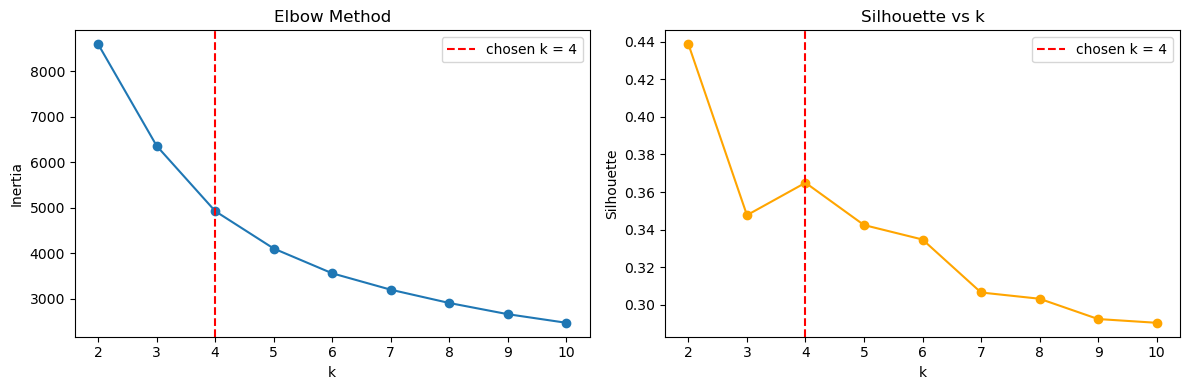

In [10]:
# Plot the two selection charts side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# LEFT: elbow plot. Look for the "bend" where the line stops dropping steeply
ax[0].plot(list(ks), inertias, 'o-') # 'o-' = circles joined by a line
ax[0].axvline(4, ls='--', c='r', label='chosen k = 4') # Red dashed line at our choice
ax[0].set(title='Elbow Method', xlabel='k', ylabel='Inertia')
ax[0].legend()

# RIGHT: silhouette plot. Higher = better separated clusters
ax[1].plot(list(ks), sils, 'o-', color='orange')
ax[1].axvline(4, ls='--', c='r', label='chosen k = 4')
ax[1].set(title='Silhouette vs k', xlabel='k', ylabel='Silhouette')
ax[1].legend()

plt.tight_layout()
plt.savefig('fig_kmeans_selection.png', dpi=150) # Figure 3.3 in the report
plt.show()

In [11]:
# Now build the FINAL model using our chosen k = 4
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)

# kmeans_labels is an array like [2, 0, 3, 1, 2, ...] - one cluster number per customer
kmeans_labels = kmeans_final.fit_predict(X)

print("K-Means fitted with k = 4")
# bincount() counts how many customers landed in cluster 0, 1, 2, 3
print("Cluster sizes:", np.bincount(kmeans_labels))

K-Means fitted with k = 4
Cluster sizes: [1973 1250 1196 1459]


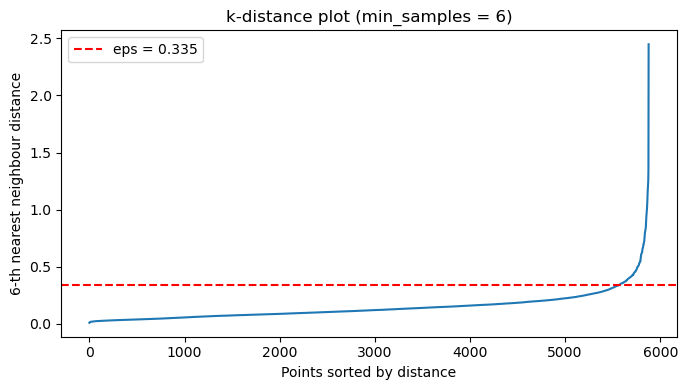

In [12]:
# Section 6: DBSCAN Clustering (Liew Qian Xue)

# min_samples = 6, using the common rule of thumb: 2 x number of features (3 RFM features)
# Too low -> everything becomes a cluster. Too high -> everything becomes noise
MIN_SAMPLES = 6

# To choose eps we build a "k-distance plot": for every customer, measure how far away their 6th nearest neighbour is
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)

# kneighbors() returns the distances to the nearest neighbours of every point
# The underscore _ means "we do not need the second return value" (the neighbour indices)
distances, _ = nn.kneighbors(X)

# distances[:, -1] takes the LAST column = distance to the 6th (furthest of the 6) neighbour
# np.sort() arranges them smallest to largest so the curve reads left to right
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.axhline(0.335, ls='--', c='r', label='eps = 0.335') # Horizontal line at our chosen eps
plt.title(f'k-distance plot (min_samples = {MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th nearest neighbour distance')
plt.legend()
plt.tight_layout()
plt.savefig('fig_kdistance.png', dpi=150) # Figure 3.4 in the report
plt.show()

In [13]:
# Build and run DBSCAN with our chosen parameters
dbscan = DBSCAN(eps=0.335, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X)

# DBSCAN labels noise as -1, so the real cluster count excludes it
# set(labels) gives the unique values; we subtract 1 if -1 is present
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# Count how many customers were labelled as noise
n_noise = int((dbscan_labels == -1).sum()) # (labels == -1) gives True/False; sum() counts the Trues

print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

Clusters found: 5
Noise points:   182 (3.1%)


In [14]:
# Build a True/False mask marking which customers DBSCAN called noise
noise_mask = dbscan_labels == -1

# Use that mask to pull out just those customers' ORIGINAL (un-scaled) RFM values
noise_customers = rfm[noise_mask]

# Compare the noise customers against the whole customer base, using the MEDIAN
# (median, not mean, because the mean is distorted by extreme values)
print("=== NOISE vs ALL customers (median) ===")
print(pd.DataFrame({
    'Noise': noise_customers.median(),
    'All':   rfm.median(),
}).round(1))

# What share of TOTAL company revenue do these "noise" customers represent?
rev_share = noise_customers['Monetary'].sum() / rfm['Monetary'].sum() * 100

print(f"\nNoise: {noise_mask.sum()} customers ({noise_mask.sum()/len(rfm)*100:.1f}% of base)")
print(f"...but {rev_share:.1f}% of total revenue.")

=== NOISE vs ALL customers (median) ===
              Noise    All
Recency       33.00  96.00
Frequency     14.50   3.00
Monetary  11,650.30 867.70

Noise: 182 customers (3.1% of base)
...but 36.7% of total revenue.


In [15]:
# Save DBSCAN's core points so the app can classify new customers
# WHY: DBSCAN has no .predict() method. But we CAN apply its own rule manually: A new point belongs to a cluster if it lies within eps of one of that cluster's "core points". Otherwise it is noise.
dbscan_data = {
    'core_points': X[dbscan.core_sample_indices_], # Coordinates of core points
    'core_labels': dbscan_labels[dbscan.core_sample_indices_], # Which cluster each belongs to
    'eps': 0.335,
}
joblib.dump(dbscan_data, 'saved_models/dbscan_core.pkl')
print(f"Saved {len(dbscan_data['core_points'])} DBSCAN core points for prediction.")

Saved 5562 DBSCAN core points for prediction.


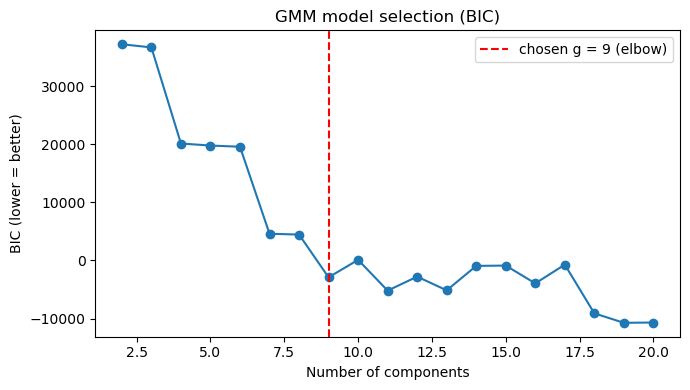

In [16]:
# Section 7: Gaussian Mixture Model [GMM] (Tan Qing Hou)

gs = range(2, 21) # test 2 up to 20 components
bics = []

for g in gs:
    # covariance_type defaults to 'full', letting each bell curve be any elliptical shape
    # n_init=3 restarts 3 times and keeps the best fit
    gmm = GaussianMixture(n_components=g, n_init=3, random_state=RANDOM_STATE)
    gmm.fit(X) # fit() trains the model (no labels needed - unsupervised)
    bics.append(gmm.bic(X)) # bic() scores this model: lower is better

plt.figure(figsize=(7, 4))
plt.plot(list(gs), bics, 'o-')
plt.axvline(9, ls='--', c='r', label='chosen g = 9 (elbow)')
plt.title('GMM model selection (BIC)')
plt.xlabel('Number of components')
plt.ylabel('BIC (lower = better)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_gmm_bic.png', dpi=150) # Figure 3.5 in the report
plt.show()

In [17]:
# Final GMM using our chosen number of components
gmm_final = GaussianMixture(n_components=9, n_init=10, random_state=RANDOM_STATE)
gmm_labels = gmm_final.fit_predict(X)

print("GMM fitted with g = 9")
print("Component sizes:", np.bincount(gmm_labels))

GMM fitted with g = 9
Component sizes: [1623  329  486   89  662 1008  359  943  379]


In [18]:
# Section 8: Model Comparison

def evaluate(labels, name):
    """Score one set of cluster labels using all three internal metrics."""

    # DBSCAN produces -1 for noise. The metrics are UNDEFINED for unassigned points, so we filter them out before scoring. (mask is True for real cluster members.)
    mask = labels != -1
    Xe, le = X[mask], labels[mask] # Xe = filtered data, le = filtered labels

    return {
        'Model': name,
        'Clusters': len(set(le)), # How many real clusters
        'Noise': int((labels == -1).sum()), # How many points excluded
        'Silhouette': round(silhouette_score(Xe, le), 4), # Higher better
        'Davies-Bouldin': round(davies_bouldin_score(Xe, le), 4), # Lower better
        'Calinski-Harabasz': round(calinski_harabasz_score(Xe, le), 1), # Higher better
    }

# Run the scoring for all three models and stack the results into one table
comparison = pd.DataFrame([
    evaluate(kmeans_labels, 'K-Means (k=4)'),
    evaluate(dbscan_labels, 'DBSCAN (eps=0.335)'),
    evaluate(gmm_labels, 'GMM (g=9)'),
])
comparison

,Model,Clusters,Noise,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (k=4),4,0,0.36,0.93,"5,058.10"
1,DBSCAN (eps=0.335),5,182,0.09,1.34,"1,313.60"
2,GMM (g=9),9,0,0.09,3.23,"1,530.90"


PCA captures 95.1% of variance in 2D


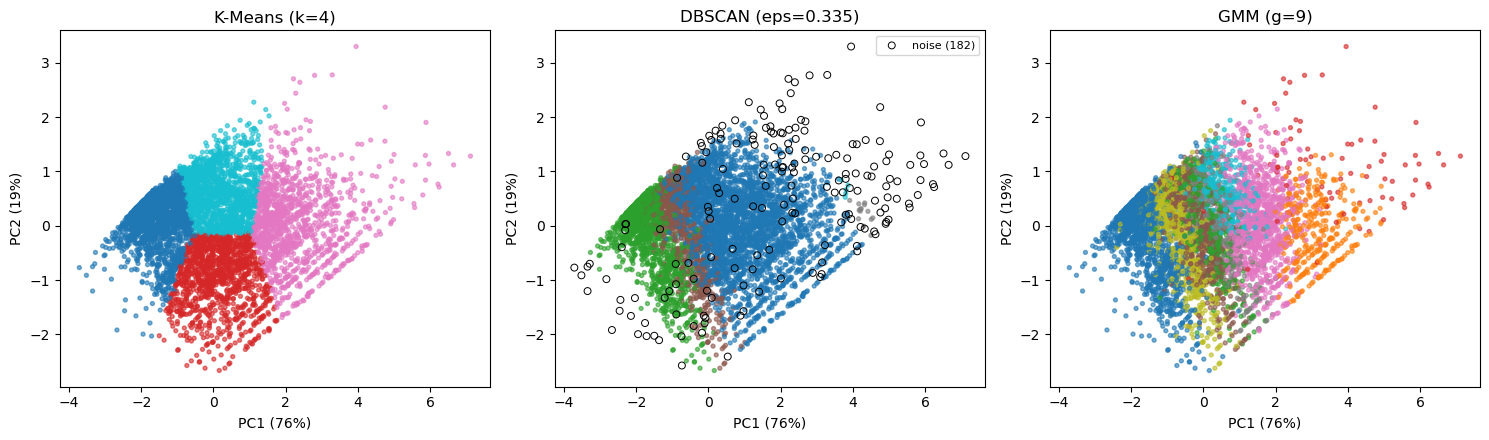

In [19]:
# Our data has 3 dimensions (R, F, M) but a screen only has 2
# PCA finds the best 2D "camera angle" that keeps as much information as possible
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X) # X2 has the same customers but only 2 coordinates each

# explained_variance_ratio_ tells us how much information survived the squashing
print(f"PCA captures {pca.explained_variance_ratio_.sum():.1%} of variance in 2D")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# zip() pairs each chart slot with one model's name and labels
for ax, (name, labels) in zip(axes, [
        ('K-Means (k=4)', kmeans_labels),
        ('DBSCAN (eps=0.335)', dbscan_labels),
        ('GMM (g=9)', gmm_labels)]):

    if -1 in labels: # only DBSCAN has noise
        m = labels == -1
        # Draw the clustered points normally, coloured by cluster
        ax.scatter(X2[~m,0], X2[~m,1], c=labels[~m], cmap='tab10', s=8, alpha=.6)
        # Draw noise points as hollow black circles so they stand out
        ax.scatter(X2[m,0], X2[m,1], facecolors='none', edgecolors='k',
                   s=25, linewidths=.7, label=f'noise ({m.sum()})')
        ax.legend(fontsize=8)
    else:
        ax.scatter(X2[:,0], X2[:,1], c=labels, cmap='tab10', s=8, alpha=.6)

    ax.set(title=name,
           xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.0%})',
           ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')

plt.tight_layout()
plt.savefig('fig_clusters_pca.png', dpi=150)
plt.show()

In [20]:
# Section 9: Segment Profiling and Naming

# assign() adds the cluster labels as a temporary column, then we group by it
profile = rfm.assign(Cluster=kmeans_labels).groupby('Cluster').agg(
    Customers=('Recency', 'size'), # 'size' just counts rows in each group
    Med_Recency=('Recency', 'median'), # median, not mean - resistant to extremes
    Med_Frequency=('Frequency', 'median'),
    Med_Monetary=('Monetary', 'median'),
).round(1)

# What percentage of all customers is each cluster?
profile['Pct_Customers'] = (profile['Customers'] / len(rfm) * 100).round(1)

# What percentage of total REVENUE does each cluster bring in?
# This is what turns a statistical result into a business insight
profile['Pct_Revenue'] = (
    rfm.assign(C=kmeans_labels).groupby('C')['Monetary'].sum()
    / rfm['Monetary'].sum() * 100
).round(1)

profile

,Customers,Med_Recency,Med_Frequency,Med_Monetary,Pct_Customers,Pct_Revenue
Cluster,,,,,,
0,1973,402.00,1.00,273.30,33.60,3.60
1,1250,24.00,3.00,734.10,21.30,6.20
2,1196,17.00,13.00,"4,986.10",20.30,73.90
3,1459,186.00,4.00,"1,450.00",24.80,16.40


In [21]:
# IMPORTANT: cluster NUMBERS are assigned arbitrarily and can change between runs
# Read the profile table above, then edit this mapping to match YOUR numbers

# How to identify each segment from the table:
# Low Recency  + high Frequency + high Monetary -> Champions
# High Recency + was frequent/high spend        -> At-Risk
# Low Recency  + low Frequency                  -> Promising
# Very high Recency + Frequency 1 + low spend   -> Dormant
segment_names = {
    2: 'Champions   (recent, frequent, high spend)',
    3: 'At-Risk     (lapsed, were valuable)',
    1: 'Promising   (recent, low frequency)',
    0: 'Dormant     (long inactive, one-off)',
}

for cluster, name in segment_names.items():
    print(f"Cluster {cluster}: {name}")

Cluster 2: Champions   (recent, frequent, high spend)
Cluster 3: At-Risk     (lapsed, were valuable)
Cluster 1: Promising   (recent, low frequency)
Cluster 0: Dormant     (long inactive, one-off)


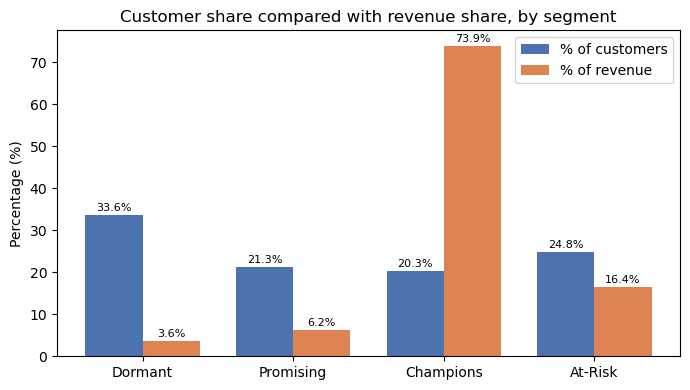

In [22]:
# Figure 4.2: Customer share vs revenue share per segment
# WHY: this is the single most important business finding. A bar chart makes the disparity immediate - one segment is a fifth of customers but three quarters of revenue, while the largest segment contributes almost nothing.

fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(profile)) # One position per cluster: 0, 1, 2, 3
width = 0.38 # Width of each bar

# Two bars side by side per cluster: shift one left, one right of centre
ax.bar(x - width/2, profile['Pct_Customers'], width,
       label='% of customers', color='#4C72B0')
ax.bar(x + width/2, profile['Pct_Revenue'], width,
       label='% of revenue', color='#DD8452')

# Label the x-axis with the business segment names, not cluster numbers
ax.set_xticks(x)
ax.set_xticklabels([segment_names.get(c, f'Cluster {c}').split('(')[0].strip()
                    for c in profile.index])

ax.set_ylabel('Percentage (%)')
ax.set_title('Customer share compared with revenue share, by segment')
ax.legend()

# Print the value on top of each bar so exact figures are readable
for i, (cust, rev) in enumerate(zip(profile['Pct_Customers'], profile['Pct_Revenue'])):
    ax.text(i - width/2, cust + 1, f'{cust}%', ha='center', fontsize=8)
    ax.text(i + width/2, rev + 1,  f'{rev}%',  ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_revenue_share.png', dpi=150)
plt.show()

In [23]:
# Save a comparison of all three algorithms so the app can display them side by side.
def build_profile(labels, name):
    """Summarise one algorithm's clusters: size, revenue share and median RFM."""
    g = rfm.assign(C=labels).groupby('C').agg(
        N=('Recency', 'size'), Rev=('Monetary', 'sum'),
        R=('Recency', 'median'), F=('Frequency', 'median'), M=('Monetary', 'median'))
    g['pct_cust'] = (g.N / len(rfm) * 100).round(1)
    g['pct_rev']  = (g.Rev / rfm.Monetary.sum() * 100).round(1)
    mask = labels != -1
    return {
        'name': name,
        'clusters': int(len(set(labels[mask]))),
        'noise': int((labels == -1).sum()),
        'silhouette': round(silhouette_score(X[mask], labels[mask]), 3),
        'davies_bouldin': round(davies_bouldin_score(X[mask], labels[mask]), 3),
        'calinski': round(calinski_harabasz_score(X[mask], labels[mask]), 0),
        'rows': g[['N', 'pct_cust', 'pct_rev', 'R', 'F', 'M']].reset_index().to_dict('records'),
    }

comparison_data = [
    build_profile(kmeans_labels, 'K-Means'),
    build_profile(dbscan_labels, 'DBSCAN'),
    build_profile(gmm_labels,    'GMM'),
]
joblib.dump(comparison_data, 'saved_models/comparison.pkl')
print("Saved comparison of all three algorithms.")

Saved comparison of all three algorithms.


In [24]:
# Export the segmented customer list for the application's management report.
# WHY: the app needs customer-level data to offer a CRM-ready download, but it does not load the raw dataset - only the saved models.
customer_export = rfm.assign(Cluster=kmeans_labels)
customer_export['Segment'] = customer_export['Cluster'].map(
    lambda c: segment_names.get(c, f'Cluster {c}').split('(')[0].strip())
customer_export.to_csv('saved_models/customer_segments.csv')
print(f"Saved customer_segments.csv ({len(customer_export):,} customers)")

Saved customer_segments.csv (5,878 customers)


In [28]:
# Section 10: Save Models for the Prototype

import os
# exist_ok=True means "do not error if the folder already exists"
os.makedirs('saved_models', exist_ok=True)

# joblib.dump(object, filename) writes a trained Python object to disk
joblib.dump(kmeans_final,  'saved_models/kmeans.pkl') # The fitted K-Means model
joblib.dump(gmm_final,     'saved_models/gmm.pkl') # The fitted GMM model
joblib.dump(scaler,        'saved_models/scaler.pkl') # ESSENTIAL - DBSCAN has no .predict() method - It cannot classify a new point without re-running on all the data. So the live app uses K-Means and GMM.
joblib.dump(segment_names, 'saved_models/segment_names.pkl') # Our business labels
profile.to_csv('saved_models/segment_profile.csv') # The profile table

print("Saved to saved_models/")
print("\nWHY save the scaler: It stores the exact mean and standard deviation learned from our 5,878 customers. \nA new customer must be scaled with those SAME values. Fitting a fresh scaler on one customer would be meaningless.")

Saved to saved_models/

WHY save the scaler: It stores the exact mean and standard deviation learned from our 5,878 customers. 
A new customer must be scaled with those SAME values. Fitting a fresh scaler on one customer would be meaningless.
